In [4]:
import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_images = glob.glob('../Data/fingers/train/*.png')
test_images = glob.glob('../Data/fingers/test/*.png')

# train data 와 test data 만들기 : 128 * 128 -> 32 * 32
train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    train_input.append(imgResize)
    train_target.append(image[-6:-4]) # -> target 은 파일명 최후단 0L, 1L 등등으로 분류

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4]) # -> target 은 파일명 최후단 0L, 1L 등등으로 분류

In [5]:
# train Data 만들기 (18000 * 32 * 32)
tempData = np.zeros(
    18000 * 32  * 32,
    dtype=np.int32
).reshape(18000, 32, 32)
tempData.shape

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i, :, :] = img
    i += 1

train_input = tempData.copy()

# test Data 만들기 (3600 * 32 * 32)
testData = np.zeros(
    3600 * 32  * 32,
    dtype=np.int32
).reshape(3600, 32, 32)
testData.shape

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    testData[i, :, :] = img
    i += 1

test_input = testData.copy()

# 배열 크기 확인
print(train_input.shape, test_input.shape)

(18000, 32, 32) (3600, 32, 32)


In [6]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

# Train Target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

# Test Target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

# Target 도 numpy배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

In [7]:
train_target

array([6, 6, 8, ..., 0, 8, 8], shape=(18000,))

In [8]:
test_target

array([11, 11,  3, ...,  4,  3,  3], shape=(3600,))

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7978 - loss: 0.6191 - val_accuracy: 0.9894 - val_loss: 0.0350
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9702 - loss: 0.0941 - val_accuracy: 0.9992 - val_loss: 0.0058
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9822 - loss: 0.0533 - val_accuracy: 0.9994 - val_loss: 0.0012
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9871 - loss: 0.0371 - val_accuracy: 1.0000 - val_loss: 4.3560e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9901 - loss: 0.0291 - val_accuracy: 1.0000 - val_loss: 3.4667e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9897 - loss: 0.0266 - val_accuracy: 1.0000 - val_loss: 8.7073e-05
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9912 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 2.5242e-04
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9936 - loss: 0.0161 - val_accura

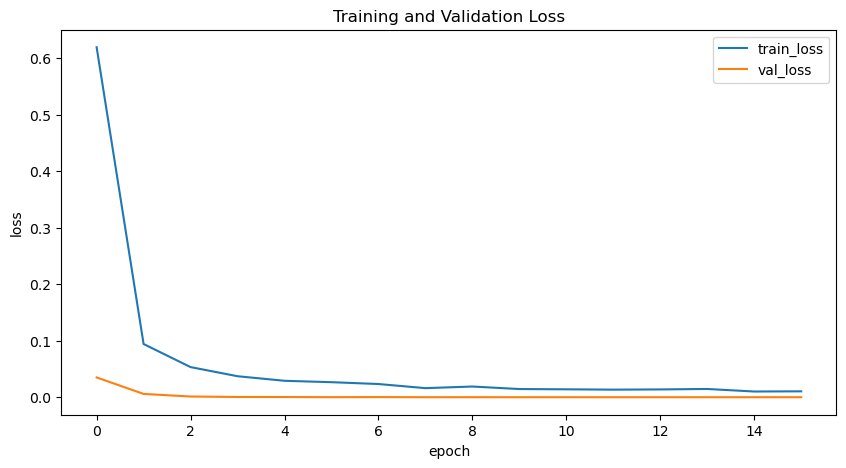

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 6.5860e-06
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
예측한 레이블: 11
실제 레이블: 11

🥇 최적의 에포크: 14 epoch
--------------------------------------------------
📈 [Train]       훈련 정확도: 99.63%
🧪 [Validation]  검증 정확도: 100.00%
🎯 [Test]        🎯 최종 테스트 정확도: 100.00%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras

# 1. 데이터 불러오기 및 전처리
# (train_input, train_target), (test_input, test_target) = (
#     keras.datasets.fashion_mnist.load_data()
# )

# 픽셀값을 0~1 사이로 정규화하고 채널 차원(1) 추가
train_scaled = train_input.reshape(-1, 32, 32, 1) / 255.0 # reshape() 함수 사용시 이미지 크기(가로, 세로) 확인하고 사용
test_scaled = test_input.reshape(-1, 32, 32, 1) / 255.0

# 검증 세트 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# 2. CNN 모델 구축
model = keras.Sequential(
    [
        # 합성곱 층 1
        keras.layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same",
            input_shape=(32, 32, 1), # 헷갈리면 위에 reshape() 함수 형태 참고하면 됨. => (이미지크기(가로, 세로)', '채널')
        ),
        keras.layers.MaxPooling2D(2),
        # 합성곱 층 2
        keras.layers.Conv2D(
            64, kernel_size=3, activation="relu", padding="same"
        ),
        keras.layers.MaxPooling2D(2),
        # 1차원으로 펼치기
        keras.layers.Flatten(),
        # 은닉층
        keras.layers.Dense(100, activation="relu"),
        # 드롭아웃 (과대적합 방지)
        keras.layers.Dropout(0.5),
        # 출력층
        keras.layers.Dense(12, activation="softmax"),
    ]
)

# 모델 컴파일
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# 3. 콜백 설정 및 모델 학습
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../Note_DL/best_cnn_model_fingers.keras", save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2, restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb],
)

# 4. 학습 결과 시각화 (손실 그래프)
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# 5. 테스트 세트 모델 평가
model.evaluate(test_scaled, test_target)

# 6. 테스트 세트 첫 번째 이미지 예측 결과 확인
predictions = model.predict(test_scaled)
predicted_label = np.argmax(predictions[0])
actual_label = test_target[0]

print(f"예측한 레이블: {predicted_label}")
print(f"실제 레이블: {actual_label}")

# 7. 최적의 에포크 인덱스 찾기 (검증 손실이 가장 낮았던 시점 기준)
val_loss_list = history.history['val_loss'] # -> model.fit() 함수 실행 결과가 자동으로 history 딕셔너리 변수에 저장됨. 해당 변수에 loss, accuracy, val_loss, val_accuracy 등이 저장됨.
best_epoch_index = np.argmin(val_loss_list) # 리스트 인덱스 (0부터 시작)
best_epoch = best_epoch_index + 1               # 실제 에포크 차수 (1부터 시작)

# 8. 최적 에포크 시점의 Train 및 Valid 정확도 추출
best_train_accuracy = history.history['accuracy'][best_epoch_index]
best_val_accuracy = history.history['val_accuracy'][best_epoch_index]

# 9. 가장 성능이 좋았던 저장된 모델을 불러와 Test 정확도 측정
best_model = keras.models.load_model('best_cnn_model_fingers.keras')
test_loss, best_test_accuracy = best_model.evaluate(test_scaled, test_target, verbose=0)

# 10. 최종 결과 출력
print("\n" + "="*50)
print(f"🥇 최적의 에포크: {best_epoch} epoch")
print("-"*50)
print(f"📈 [Train]       훈련 정확도: {best_train_accuracy * 100:.2f}%")
print(f"🧪 [Validation]  검증 정확도: {best_val_accuracy * 100:.2f}%")
print(f"🎯 [Test]        🎯 최종 테스트 정확도: {best_test_accuracy * 100:.2f}%")
print("="*50)

> Early Stopping , Drop Out 기능 모두 탑재.

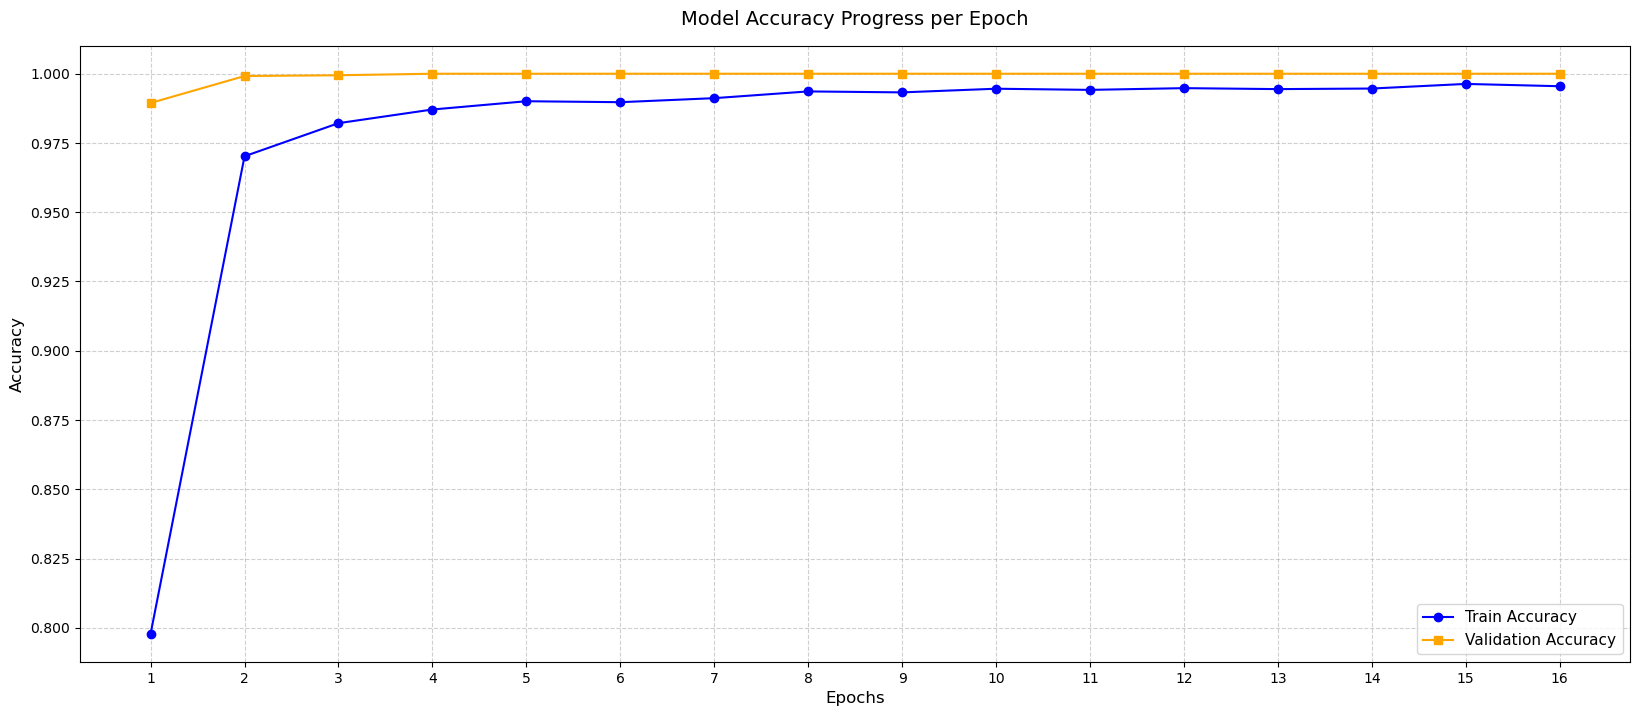

In [10]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()